# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Khor Qi Jun



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [2]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import joblib
 
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import (accuracy_score, f1_score, fbeta_score, make_scorer, classification_report, confusion_matrix, precision_recall_curve)

# 1. Business Understanding
Problem: Wine quality is currently assessed via manual sensory panels. It is slow, expensive, and subjective. A distributor or winery sourcing white wine in bulk needs a fast, consistent way to flag likely "Premium" bottles (expert-rated quality >= 7) for priority tasting and quality control review, using only lab measurable physicochemical properties (alcohol, acidity, sulphates, ...) that are already captured during production.

Goal: Build a binary classifier that predicts Premium vs Standard from these lab measurements, so quality control teams can prioritize review effort instead of tasting every batch equally.

Why classification, not regression: the business decision is binary (flag for review, or don't). Predicting the exact 1-9 score adds precision the quality control workflow doesn't need, and would require optimizing a much harder target for no added business value.

# 2. Data Understanding

## 2.1 Load dataset

In [3]:
## Read *.csv file into pandas DataFrame
FILE_PATH = r"C:\Users\khorq\Downloads\winequality-white.csv"
df = pd.read_csv(FILE_PATH, sep=';')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


## 2.2 Summary Statistics

In [4]:
## Understand the type of variable for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [5]:
## Check for missing data. If this comes back non-zero, I need to decide on an imputation strategy before doing anything else, but this dataset has none.
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [6]:
## Describe data distribution. Mainly used this to sanity-check ranges (example: does pH actually sit between 2-4 like it should) before trusting any of it.)
df.describe(include="all")

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


## 2.3 Data Visualization

### 2.3.1 Distribution of target

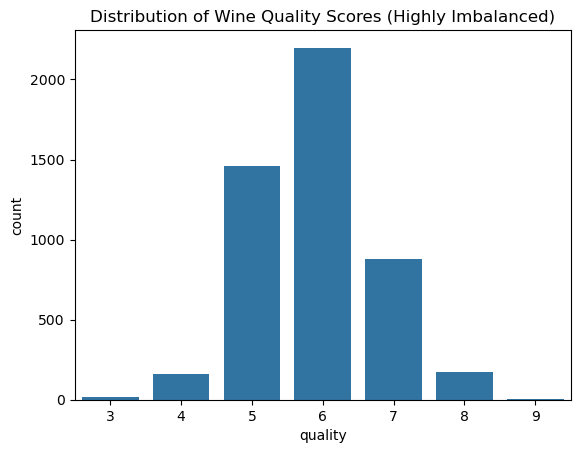

In [7]:
sns.countplot(x=df['quality'])
plt.title("Distribution of Wine Quality Scores (Highly Imbalanced)")
plt.show()

Most wines score 5 or 6 on quality (about 75% of the dataset), and very few score at the extremes (only 20 wines rated 3, just 5 rated 9). Premium wines (quality 7 or higher) make up roughly 21% of the data. This matters for picking a metric because a model that just guessed "Standard" for every wine would be right about 79% of the time and still be completely useless for the business, so accuracy alone would hide how badly it's actually doing. F1 is the better fit here because it forces the model to actually find the minority class instead of getting a free pass for ignoring it.

### 2.3.2 Distribution of Features

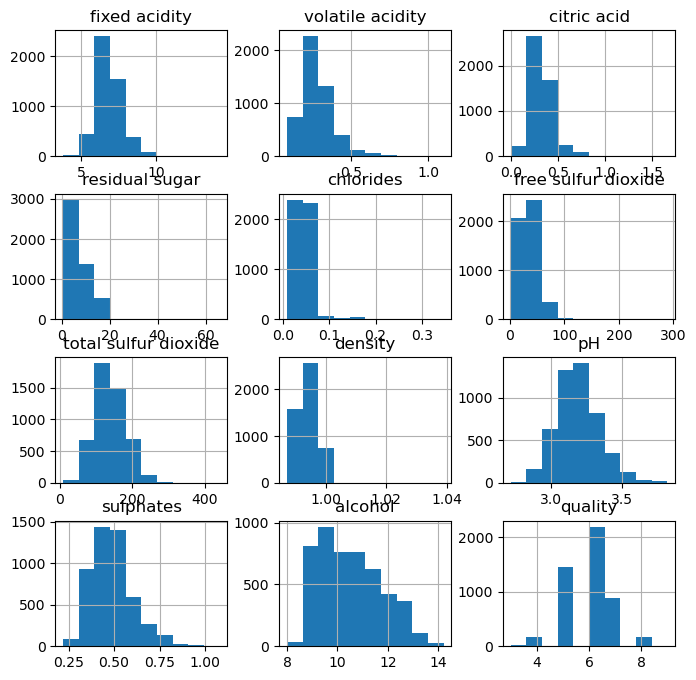

In [8]:
## Understanding distribution of features
df.hist(figsize=(8,8))
plt.show()

Most of these are right-skewed rather than symmetric, a handful of wines pull the tail out toward high values while the bulk sit low. Chlorides is the most extreme case (skewness of about 5.0), with free sulfur dioxide, volatile acidity, residual sugar, citric acid, and density all showing noticeable skew too. Alcohol, pH, and total sulfur dioxide are closer to symmetric. This is part of why I tested a log transformation on the most skewed features in the feature engineering section and it's also a point in favor of Random Forest over a linear model here: tree-based models don't assume features are normally distributed the way linear/logistic regression often benefits from, so this skew isn't something I need to "fix" for the model to work well, just something worth being aware of.

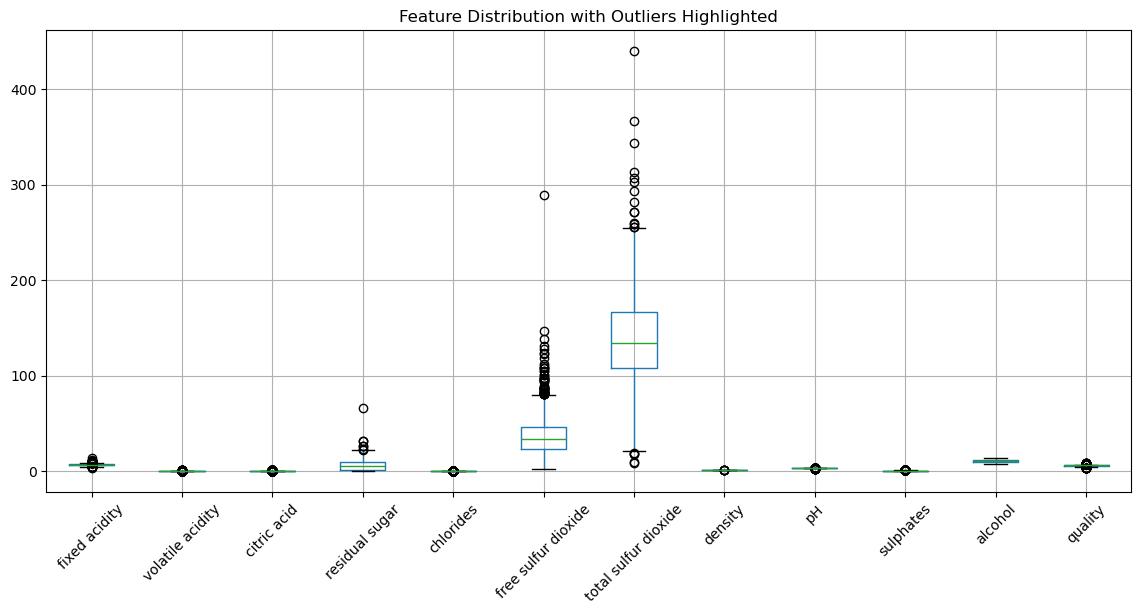

In [9]:
# Much better size for 11 columns
plt.figure(figsize=(14, 6))  # Wide enough to read
df.boxplot(rot=45)
plt.title("Feature Distribution with Outliers Highlighted")
plt.show()

Free sulfur dioxide, total sulfur dioxide and residual sugar show the most extreme outliers here (values several times their own 99th percentile). I test in Data Preparation whether capping these actually helps a tree-based model, or whether it just throws away real information. it actaully made the results worse when I capped the outliers.

### 2.3.3 Alcohol vs Quality

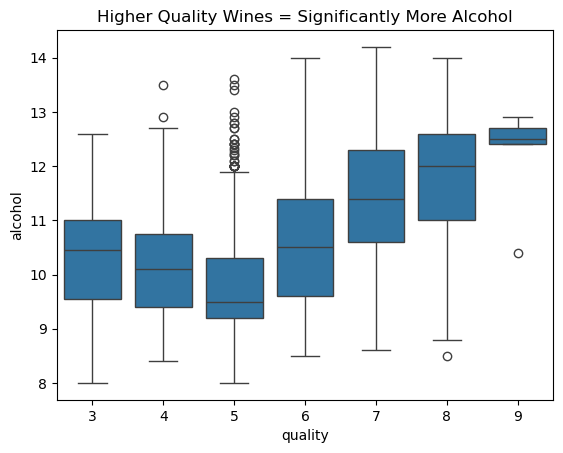

In [10]:
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title("Higher Quality Wines = Significantly More Alcohol")
plt.show()

Premium wines tend to have noticeably higher alcohol content than Standard ones, and the boxes barely overlap in the middle. That makes alcohol a useful signal on its own, but not a reliable rule by itself. A wine sitting around 10 5% alcohol shows up in both groups, so a simple "high alcohol equals premium" cutoff would get plenty of wines wrong. That's the case for letting the model weigh alcohol alongside the other ten features rather than relying on any single one.

### 2.3.4 Relationships Between Variables

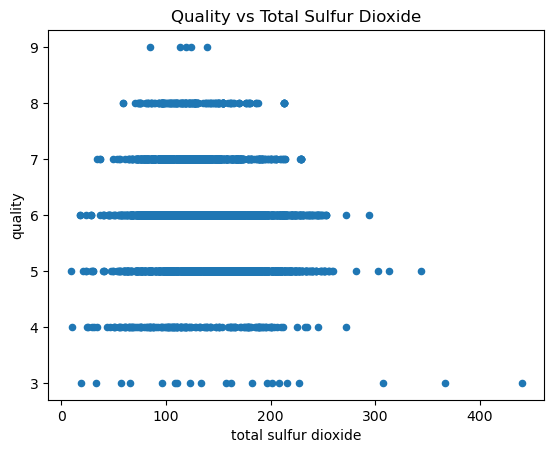

In [11]:
## Plot scatterplot
col_x = 'total sulfur dioxide'
col_y = 'quality'

df.plot(x=col_x,
        y=col_y,
        kind='scatter')
plt.title(f"Quality vs Total Sulfur Dioxide")
plt.suptitle('')  # Remove default title by Pandas
plt.xlabel(col_x)
plt.ylabel(col_y)
plt.show()

Did the same scatter for every feature against quality, mostly to check for anything obviously linear I could exploit, or any weird clusters/outliers that would need cleaning before modelling.

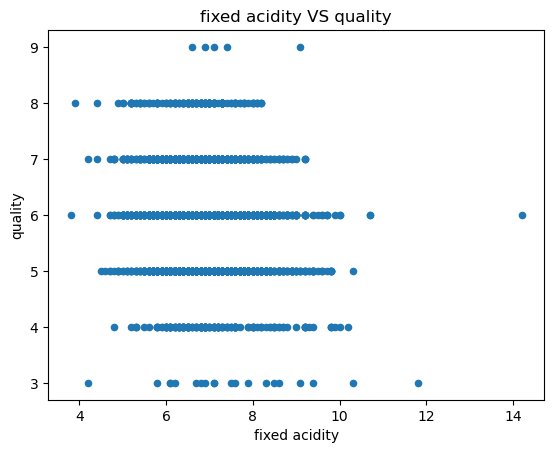

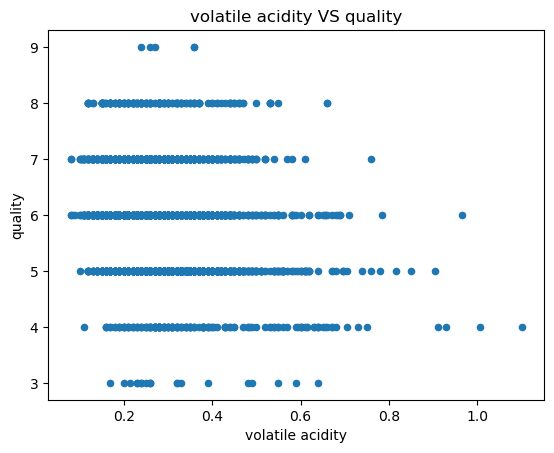

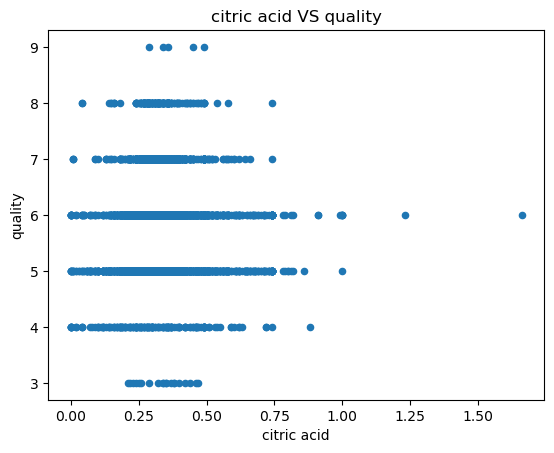

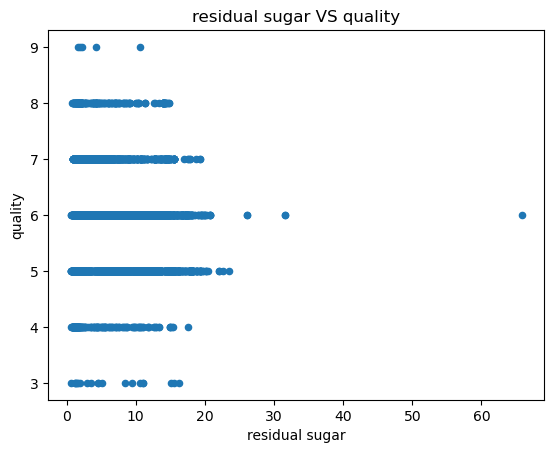

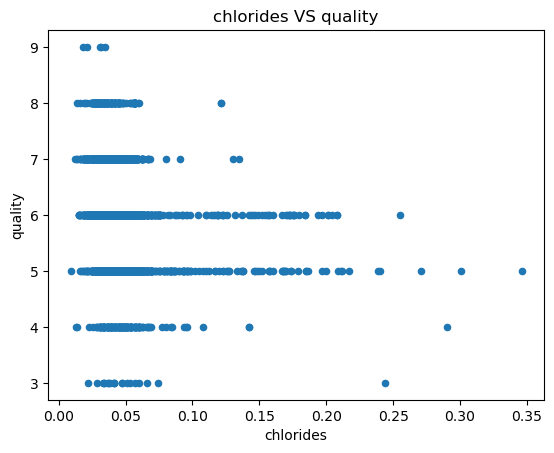

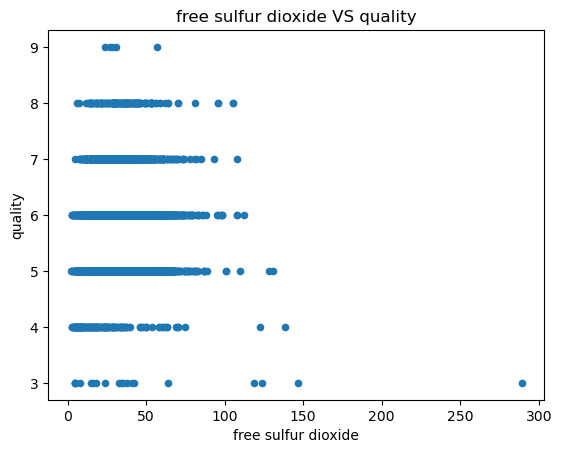

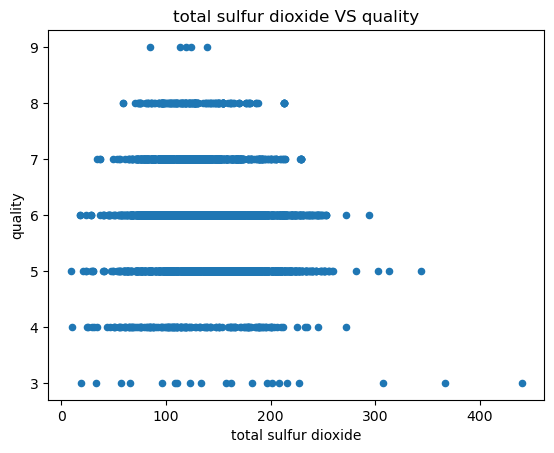

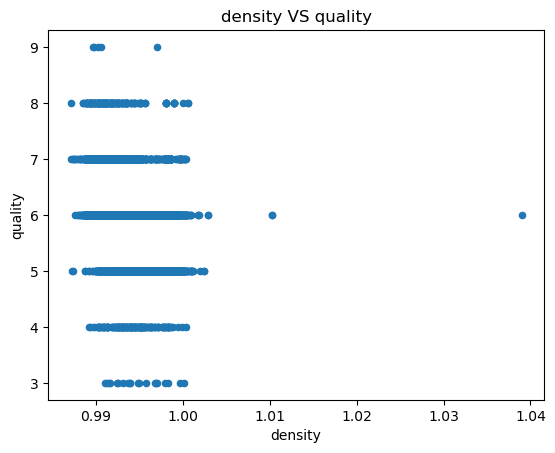

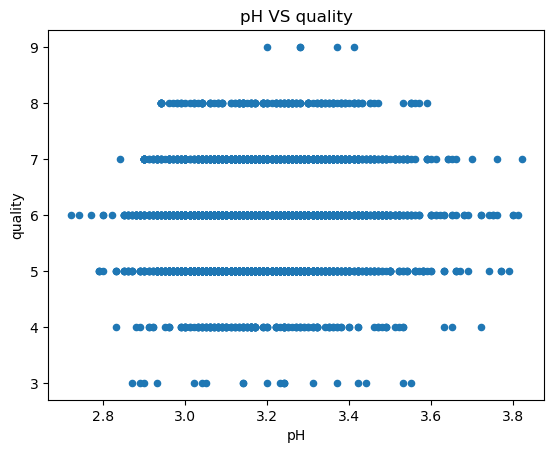

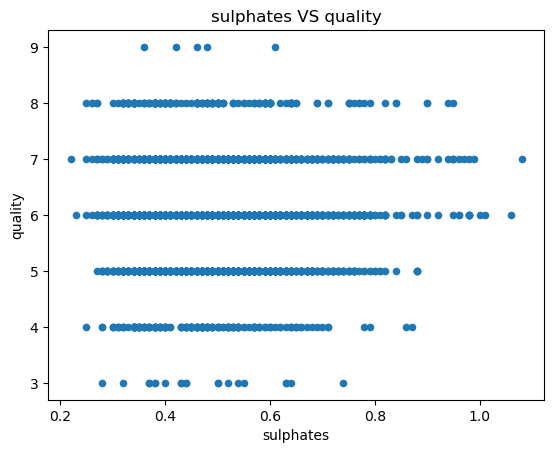

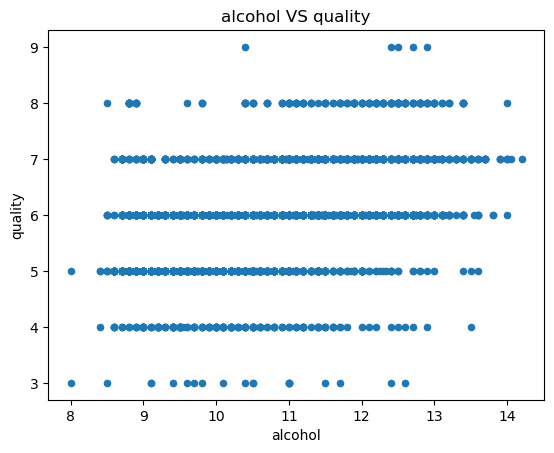

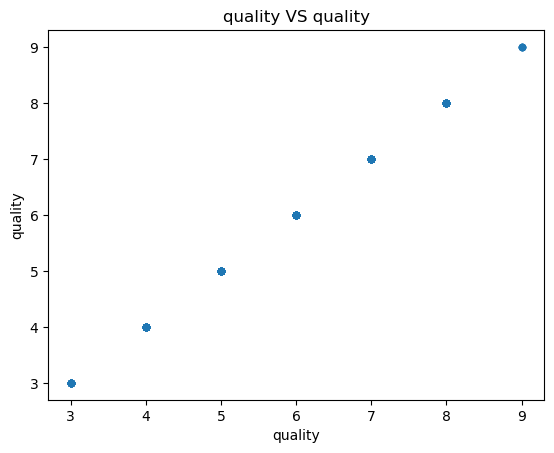

In [12]:
for col_x in df.columns:
    df.plot(x=col_x,
            y=col_y,
            kind='scatter')
    plt.title(f"{col_x} VS quality")
    plt.suptitle('')  # Remove default title by Pandas
    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.show()

None of these show an obvious step change or clean threshold separating Premium from Standard wines, quality creeps up gradually with features like alcohol rather than flipping at some clear cutoff. That's a useful negative result as it tells us a simple rule based system (example it will flag if alcohol > X) would miss most of the signal, and supports using a model that can weigh several features together instead.

In [13]:
## Understanding relationship between variables
col_numeric = df.select_dtypes(include=['float', 'int']).columns ## Select all categorical columns

## Display correlation matrix
df_corr = df[col_numeric].corr()
df_corr

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.022697,0.289181,0.089021,0.023086,-0.049396,0.091070,0.265331,-0.425858,-0.017143,-0.120881,-0.113663
volatile acidity,-0.022697,1.000000,-0.149472,0.064286,0.070512,-0.097012,0.089261,0.027114,-0.031915,-0.035728,0.067718,-0.194723
citric acid,0.289181,-0.149472,1.000000,0.094212,0.114364,0.094077,0.121131,0.149503,-0.163748,0.062331,-0.075729,-0.009209
residual sugar,0.089021,0.064286,0.094212,1.000000,0.088685,0.299098,0.401439,0.838966,-0.194133,-0.026664,-0.450631,-0.097577
chlorides,0.023086,0.070512,0.114364,0.088685,1.000000,0.101392,0.198910,0.257211,-0.090439,0.016763,-0.360189,-0.209934
free sulfur dioxide,-0.049396,-0.097012,0.094077,0.299098,0.101392,1.000000,0.615501,0.294210,-0.000618,0.059217,-0.250104,0.008158
total sulfur dioxide,0.091070,0.089261,0.121131,0.401439,0.198910,0.615501,1.000000,0.529881,0.002321,0.134562,-0.448892,-0.174737
density,0.265331,0.027114,0.149503,0.838966,0.257211,0.294210,0.529881,1.000000,-0.093591,0.074493,-0.780138,-0.307123
pH,-0.425858,-0.031915,-0.163748,-0.194133,-0.090439,-0.000618,0.002321,-0.093591,1.000000,0.155951,0.121432,0.099427
sulphates,-0.017143,-0.035728,0.062331,-0.026664,0.016763,0.059217,0.134562,0.074493,0.155951,1.000000,-0.017433,0.053678


### 2.3.5 Correlation Analysis

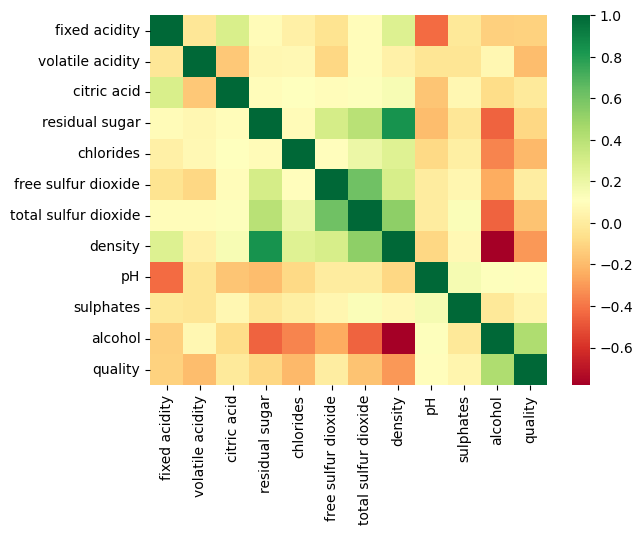

In [14]:
sns.heatmap(df_corr, cmap='RdYlGn')
plt.show()

No feature shows a strong (|r| > 0.5) linear correlation with quality individually, the strongest, alcohol, is only 0.436. This tells us the relationship is likely non-linear and spread across multiple features, which is why a tree-based ensemble (able to model interactions and thresholds) is a better fit here than a linear model.

### 2.3.6 Pairwise Relationships (Premium vs Standard)

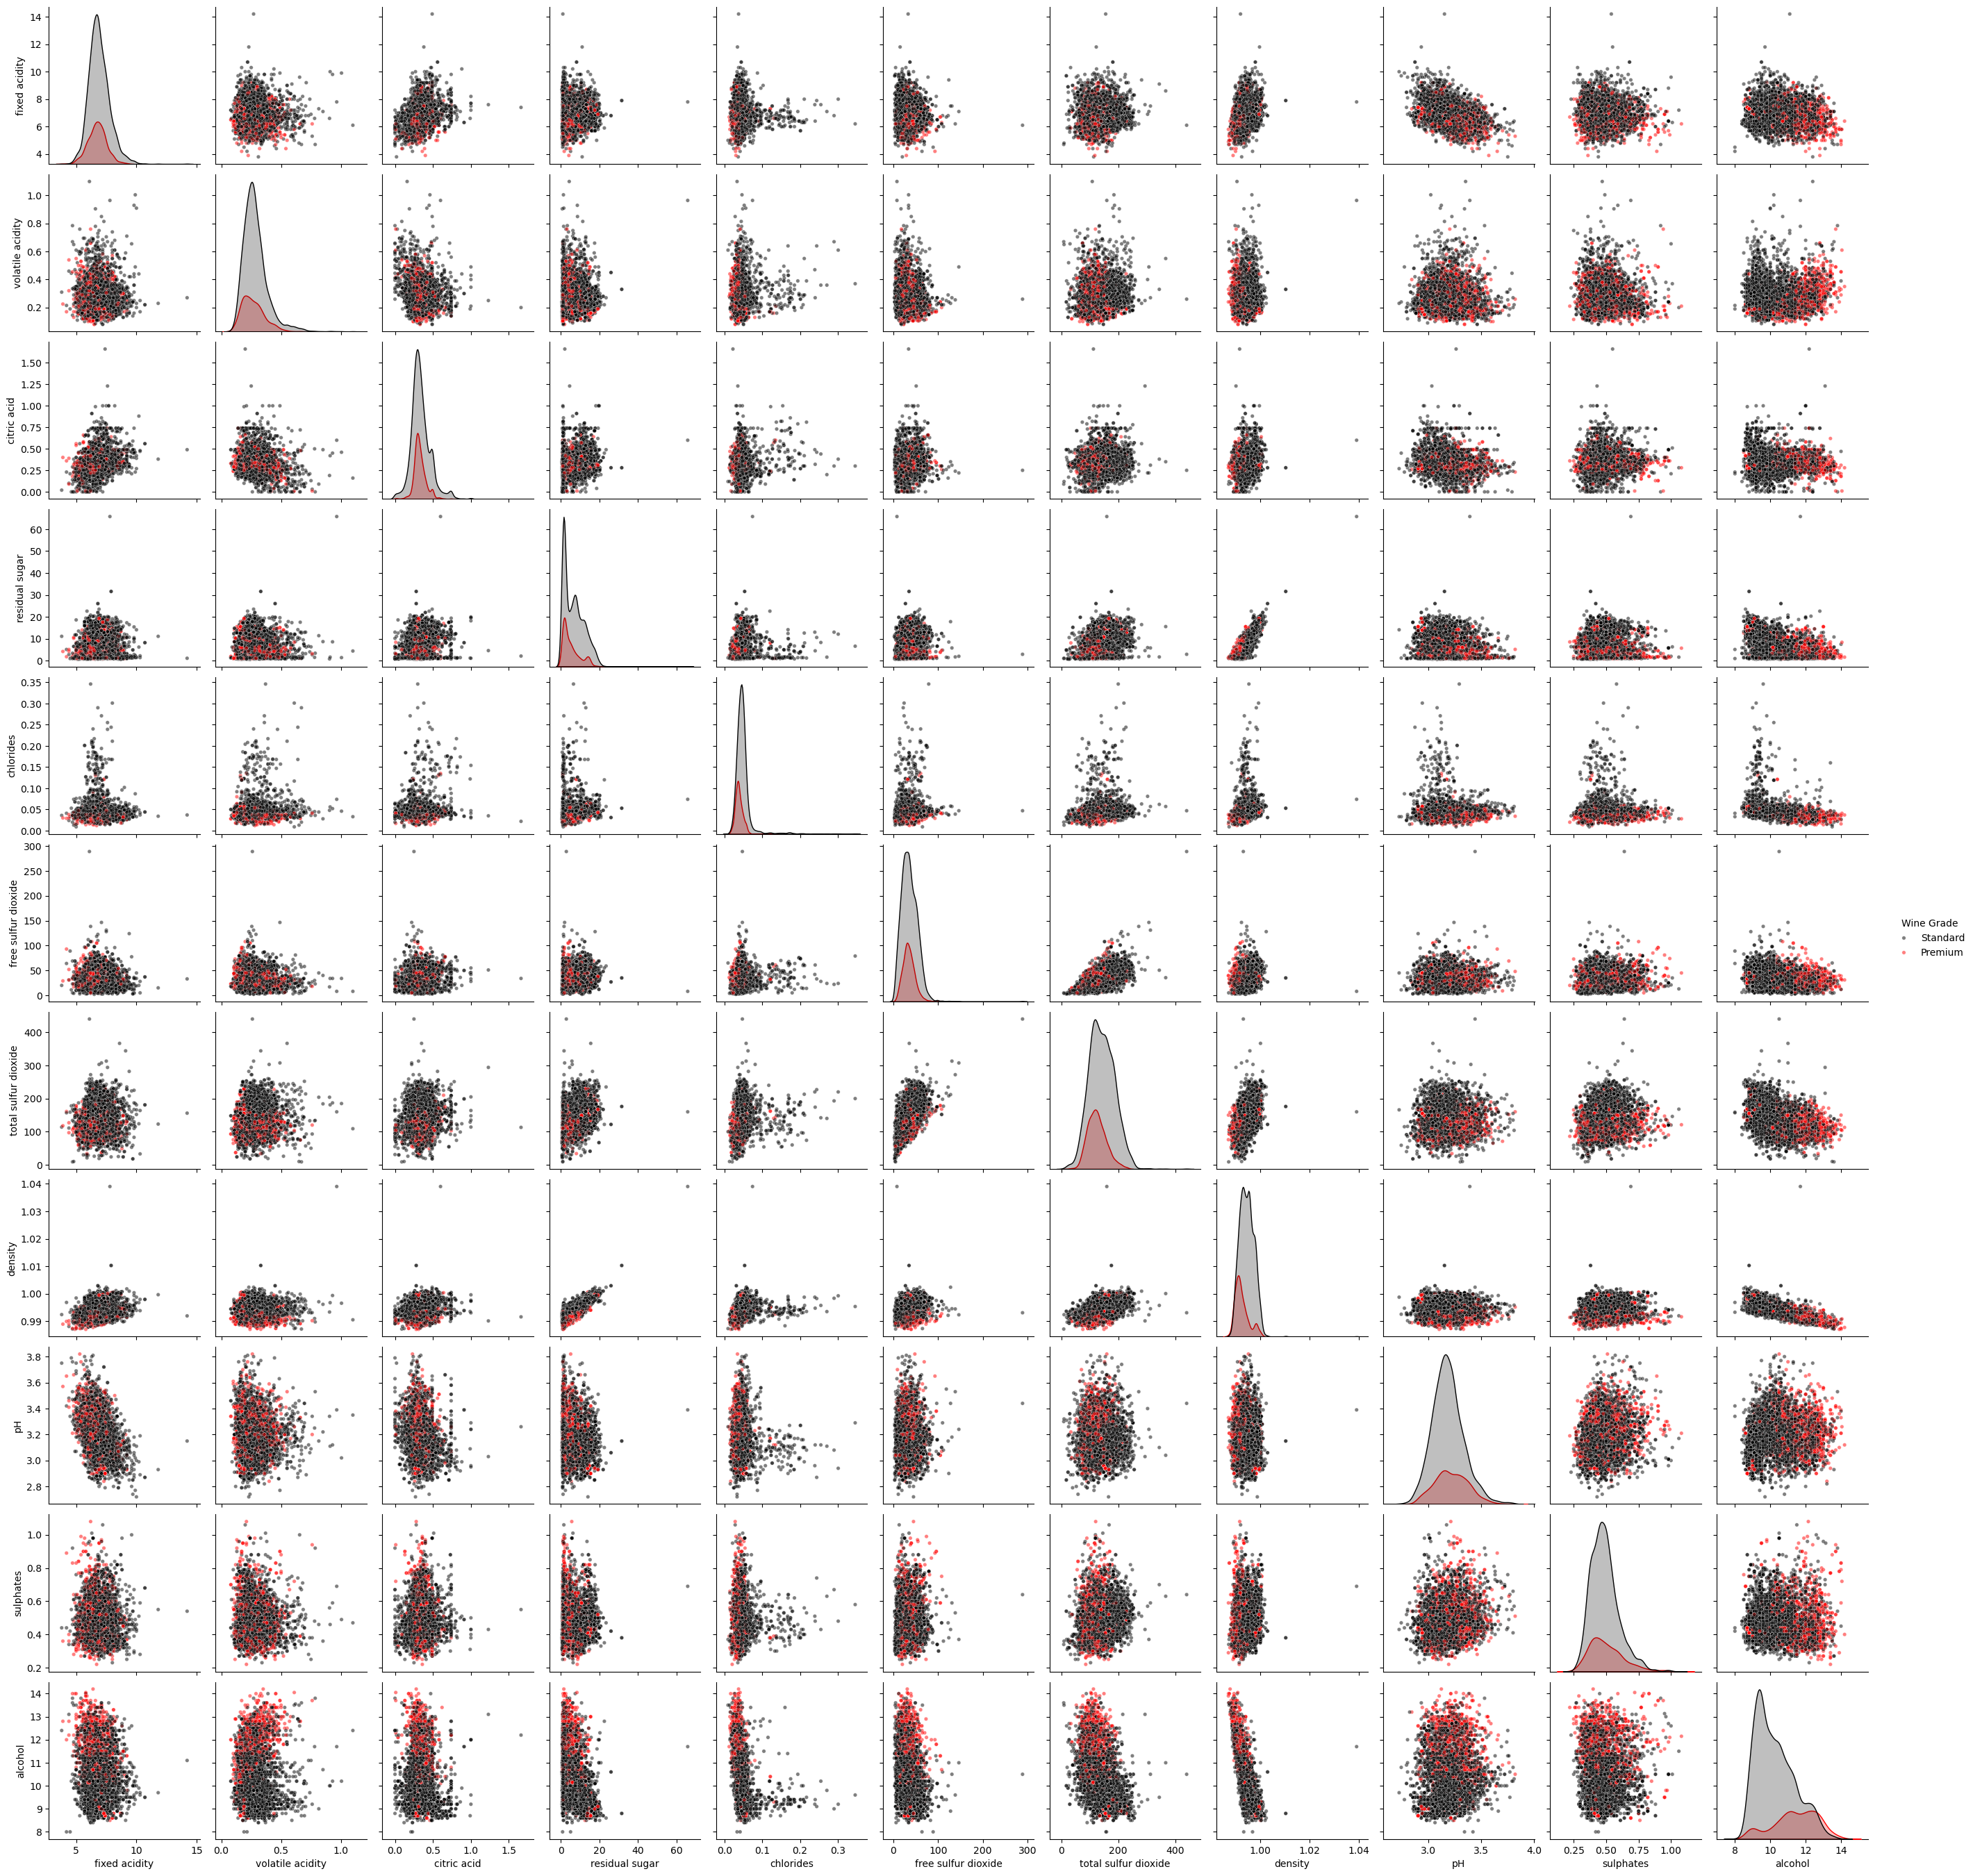

In [15]:
## Plot pairplot
df_plot = df.copy()
df_plot['Wine Grade'] = np.where(df_plot['quality'] >= 7, 'Premium', 'Standard')
sns.pairplot(
    df_plot.drop(columns=['quality']),
    hue='Wine Grade',
    palette={'Standard': "#000000", 'Premium': "#FF0000"},
    plot_kws={'alpha': 0.5, 's': 15},
)
plt.show()

No pairwise combination here cleanly separates the Premium (red) points from Standard ones (black one), they're intermingled across every panel. Combined with the scatter plots above, this reinforces that quality isn't explained by any single feature or simple two feature combination, which is the case for a tree based ensemble over a simpler rule or linear model.

# 3. Data Preparation

### 3.1 Data Cleaning

In [16]:
print(f"Rows before: {len(df)}") 
df.drop_duplicates(inplace=True)
print(f"Rows after: {len(df)}")

Rows before: 4898
Rows after: 3961


Dropping duplicates before the train/test split matters a lot here. If I split first and dedup later, or don't dedup at all, the same exact wine can end up in both the training set and the test set. The model would then get "tested" on a row it already memorised during training, which quietly inflates the test F1 score and gives a false sense of how well the model actually generalises. I found this the hard way when my reported F1 dropped once I fixed it, that drop is the leakage disappearing, not the model getting worse.

In [17]:
X = df.drop(columns=['quality'])
y = df['quality']
y_binary = (y >= 7).astype(int) # 1 = Premium wine, 0 = Standard wine
 
print(f"\nFeatures used ({X.shape[1]}): {X.columns.tolist()}")
print(f"Class balance -> Standard (0): {(y_binary == 0).sum()}  |  Premium (1): {(y_binary == 1).sum()}")


Features used (11): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Class balance -> Standard (0): 3136  |  Premium (1): 825


I'll be keeping all 11 features here, not just a subset. Every feature showed some correlation with quality in the heatmap above, none of them are close to zero, so there's no evidence-based reason to drop any of them. Random Forest also handles correlatedor redundant features fine (unlike linear model), so there's no real cost to keeping them all in.

In [18]:
print("Outlier capping tested and intentionally not applied, see comment above for the evidence.")

Outlier capping tested and intentionally not applied, see comment above for the evidence.


A few features have some genuinely extreme values, up to 3.5x their own 99th percentile. Our first instinct was to cap the worst-looking ones at the 99th percentile, the way you'd do for a linear model where a handful of extreme rows can drag the fitted line around. But Random Forest doesn't work that way, it splits on ordered thresholds, not raw magnitude, so a few extreme values don't distort its decision boundary the way they would for a linear or distance-based model. I actually tested it rather than assuming: capping never helped and capping only a subset of features was the worst option of all, worse than capping everything, worse than capping nothing.
   No capping at all:        F1 = 0.6078
   Capping all 11 features:  F1 = 0.6010
   Capping only 3 features:  F1 = 0.5917  (our original, inconsistent choice)

So I'm keeping every value as-is. Capping was throwing away real information (the difference between "high" and "extremely high") without fixing a problem this model actually has.

### 3.2 Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print("TARGET CONVERTED TO BINARY")
print(f"Standard (0): {sum(y_train == 0)} wines")
print(f"Premium (1):  {sum(y_train == 1)} wines")

TARGET CONVERTED TO BINARY
Standard (0): 2508 wines
Premium (1):  660 wines


stratify=y_binary keeps the ~79/21 Standard/Premium split roughly the same in both the train and test sets. Without it, a random split could easily leave the test set with barely any Premium wines, given how few there are to begin with, which would make the F1 score on the test set unreliable.

# 4. Modelling

### 4.1 Train Model

Training three different algorithms on the exact same train test split before touching any tuning, so the comparison is fair. class_weight is set to 'balanced' wherever supported since Premium is only ~21% of the data, without it the models would just lean toward predicting Standard every time and still look decent on accuracy while being useless for the business goal.

### 4.1 Baseline Model Comparison

In [20]:
print("\n1. DECISION TREE CLASSIFIER")

dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
 
acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, pos_label=1)
print(f"Accuracy: {acc_dt:.4f}")
print(f"F1-Score (Premium): {f1_dt:.4f}")
print("\n", classification_report(y_test, y_pred_dt, target_names=['Standard', 'Premium'], digits=3))

joblib.dump(dt, 'wine_binary_dt_model.pkl')
print("Saved as 'wine_binary_dt_model.pkl'\n")


1. DECISION TREE CLASSIFIER
Accuracy: 0.7415
F1-Score (Premium): 0.3807

               precision    recall  f1-score   support

    Standard      0.837     0.836     0.837       628
     Premium      0.380     0.382     0.381       165

    accuracy                          0.741       793
   macro avg      0.608     0.609     0.609       793
weighted avg      0.742     0.741     0.742       793

Saved as 'wine_binary_dt_model.pkl'



In [21]:
print("2. GRADIENT BOOSTING")

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
 
gbt = GradientBoostingClassifier(random_state=42)
gbt.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_gbt = gbt.predict(X_test)
 
acc_gbt = accuracy_score(y_test, y_pred_gbt)
f1_gbt = f1_score(y_test, y_pred_gbt, pos_label=1)
print(f"Accuracy: {acc_gbt:.4f}")
print(f"F1-Score (Premium): {f1_gbt:.4f}")
print("\n", classification_report(y_test, y_pred_gbt, target_names=['Standard', 'Premium'], digits=3))

joblib.dump(gbt, 'wine_binary_gbt_model.pkl')
print("Saved as 'wine_binary_gbt_model.pkl'\n")

2. GRADIENT BOOSTING
Accuracy: 0.7491
F1-Score (Premium): 0.5626

               precision    recall  f1-score   support

    Standard      0.926     0.742     0.824       628
     Premium      0.441     0.776     0.563       165

    accuracy                          0.749       793
   macro avg      0.684     0.759     0.693       793
weighted avg      0.826     0.749     0.770       793

Saved as 'wine_binary_gbt_model.pkl'



GradientBoostingClassifier doesn't have a class_weight parameter like the other two models do, so I get the same effect manually with sample_weight, giving the rarer Premium rows more weight when the model is being trained.

In [22]:
print("3. RANDOM FOREST (FINAL MODEL)")


rf_params = {
    'n_estimators': 100,
    'max_depth': 10,
    'min_samples_split': 20,
    'min_samples_leaf': 10,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1
}
 
rf_baseline_full = RandomForestClassifier(**rf_params)
rf_baseline_full.fit(X_train, y_train)
y_pred_baseline_full = rf_baseline_full.predict(X_test)
 
baseline_f1 = f1_score(y_test, y_pred_baseline_full, pos_label=1)
baseline_acc = accuracy_score(y_test, y_pred_baseline_full)
 
print(f"Accuracy: {baseline_acc:.4f}")
print(f"F1-Score (Premium): {baseline_f1:.4f}")
print("\n", classification_report(y_test, y_pred_baseline_full, target_names=['Standard', 'Premium'], digits=3))

joblib.dump(rf_baseline_full, 'wine_final_model.pkl')
print("Saved as 'wine_final_model.pkl'\n")

3. RANDOM FOREST (FINAL MODEL)
Accuracy: 0.7982
F1-Score (Premium): 0.6078

               precision    recall  f1-score   support

    Standard      0.925     0.811     0.864       628
     Premium      0.510     0.752     0.608       165

    accuracy                          0.798       793
   macro avg      0.718     0.781     0.736       793
weighted avg      0.839     0.798     0.811       793

Saved as 'wine_final_model.pkl'



Deliberately not letting this grow deep or unrestricted. An early test with no depth limit actually scored WORSE (it overfits the majority class hard despite class_weight='balanced'), so these settings are a starting point I picked precisely because unrestricted trees performed badly, not just a guess. This gets refined properly in the tuning section further down.

I'll be saving it under its own filename, not 'wine_final_model.pkl', on purpose. This is just the untuned baseline, I don't want it accidentally mistaken for (or overwriting) the actual final model saved at the end of the notebook.


In [23]:
baseline_comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Gradient Boosting', 'Random Forest'],
    'Accuracy': [acc_dt, acc_gbt, baseline_acc],
    'F1 (Premium)': [f1_dt, f1_gbt, baseline_f1],
}).sort_values('F1 (Premium)', ascending=False)
 
print("BASELINE MODEL COMPARISON (11 features, same train/test split)")
print(baseline_comparison.to_string(index=False))
print(f"\nSelected for tuning: Random Forest "
      f"(highest F1={baseline_f1:.4f}; also more stable/less overfit-prone "
      f"than GBT on noisy human-rated labels, and more interpretable via "
      f"feature_importances_ than boosting for the investor pitch)")

BASELINE MODEL COMPARISON (11 features, same train/test split)
            Model  Accuracy  F1 (Premium)
    Random Forest  0.798235      0.607843
Gradient Boosting  0.749054      0.562637
    Decision Tree  0.741488      0.380665

Selected for tuning: Random Forest (highest F1=0.6078; also more stable/less overfit-prone than GBT on noisy human-rated labels, and more interpretable via feature_importances_ than boosting for the investor pitch)


# 5. Model Evaluation

### 5.1 Best model

In [39]:
final_model = best_rf

### 5.2 Generate predictions on unseen test data

In [40]:
y_pred_final = final_model.predict(X_test)

### 5.3 Classification report

In [41]:
print("CLASSIFICATION REPORT (Test Set - Premium = 1)")
print(classification_report(y_test, y_pred_final, target_names=['Standard (0)', 'Premium (1)']))

CLASSIFICATION REPORT (Test Set - Premium = 1)
              precision    recall  f1-score   support

Standard (0)       0.92      0.83      0.87       628
 Premium (1)       0.52      0.72      0.60       165

    accuracy                           0.80       793
   macro avg       0.72      0.77      0.74       793
weighted avg       0.83      0.80      0.81       793



### 5.4 Confusion matrix


CONFUSION MATRIX (Test Set)


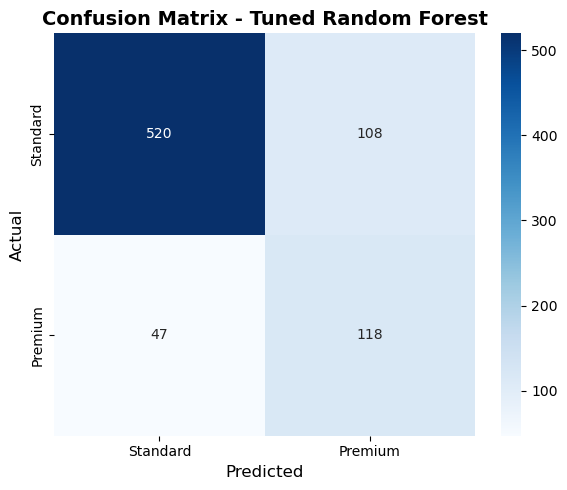

In [42]:
print("\nCONFUSION MATRIX (Test Set)")

cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Standard', 'Premium'],
            yticklabels=['Standard', 'Premium'])
ax.set_title('Confusion Matrix - Tuned Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

### 5.5 Confusion matrix interpretation

In [43]:
tn, fp, fn, tp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]

print("\nCONFUSION MATRIX INTERPRETATION")
print(f"True Negatives (Standard correctly identified): {tn}")
print(f"False Positives (Standard mislabeled as Premium): {fp}")
print(f"False Negatives (Premium missed): {fn}")
print(f"True Positives (Premium correctly identified): {tp}")
print(f"\nBusiness Impact:")
print(f"   {tp} premium wines caught out of {tp + fn} total premium wines")
print(f"   Catch Rate: {tp/(tp+fn)*100:.1f}%")


CONFUSION MATRIX INTERPRETATION
True Negatives (Standard correctly identified): 520
False Positives (Standard mislabeled as Premium): 108
False Negatives (Premium missed): 47
True Positives (Premium correctly identified): 118

Business Impact:
   118 premium wines caught out of 165 total premium wines
   Catch Rate: 71.5%


This "catch rate" is really the number that matters to the business, since the whole point of the tool is not missing too many genuinely good wines.

#### 5.6 Final Model Summary & Deployment Artifact

In [44]:
print("FINAL MODEL PERFORMANCE SUMMARY")
print(f"Selected Model: Tuned Random Forest")
print(f"Test Accuracy:  {tuned_acc:.4f}")
print(f"Test F1 (Premium): {tuned_f1:.4f}")
print(f"Best Hyperparameters: {search_rf.best_params_}")
print(f"Best CV F1: {search_rf.best_score_:.4f}")
print("\nModel is ready for deployment.")

FINAL MODEL PERFORMANCE SUMMARY
Selected Model: Tuned Random Forest
Test Accuracy:  0.8045
Test F1 (Premium): 0.6036
Best Hyperparameters: {'n_estimators': 300, 'min_samples_split': 20, 'max_depth': 10}
Best CV F1: 0.5744

Model is ready for deployment.


Bundling the model together with its threshold and the exact feature order it expects, not just the raw model, because the Streamlit app needs all three of those to make a correct prediction. Saving just the model and hardcoding 0.5 elsewhere would quietly throw away the threshold tuning work above.

## 6. Iterative model development

### 6.1 Hyperparameter Tuning

In [25]:
premium_scorer = make_scorer(f1_score, pos_label=1)
 
rf_tune = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
 
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],          # keep reasonable, unrestricted depth overfits badly here
    'min_samples_split': [5, 10, 20]    # higher = less overfitting on the minority class
}
 
search_rf = RandomizedSearchCV(
    rf_tune,
    param_grid,
    n_iter=10,
    cv=5,
    scoring=premium_scorer,
    random_state=42,
    n_jobs=-1
)
search_rf.fit(X_train, y_train)


cv_log = pd.DataFrame(search_rf.cv_results_)[
    ['param_n_estimators', 'param_max_depth', 'param_min_samples_split', 'mean_test_score', 'std_test_score']
].sort_values('mean_test_score', ascending=False)
print("RANDOMIZEDSEARCHCV RESULTS (all 10 sampled configs)")
print(cv_log.to_string(index=False))
 
print("HYPERPARAMETER TUNING — RANDOM FOREST")
print(f"Best Parameters: {search_rf.best_params_}")
print(f"Best CV F1-Score (Premium): {search_rf.best_score_:.4f}")
 
best_rf = search_rf.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
tuned_f1 = f1_score(y_test, y_pred_tuned, pos_label=1)
tuned_acc = accuracy_score(y_test, y_pred_tuned)
 
print(f"\nTEST SET PERFORMANCE (Tuned)")
print(f"Accuracy: {tuned_acc:.4f}")
print(f"F1 (Premium): {tuned_f1:.4f}  (baseline was {baseline_f1:.4f}, change {tuned_f1 - baseline_f1:+.4f})")

RANDOMIZEDSEARCHCV RESULTS (all 10 sampled configs)
 param_n_estimators  param_max_depth  param_min_samples_split  mean_test_score  std_test_score
                300               10                       20         0.574425        0.041878
                100               10                        5         0.568973        0.045915
                300               15                       20         0.564821        0.047630
                200               15                       20         0.558816        0.051213
                100               20                       20         0.553233        0.061823
                100               15                       10         0.544194        0.059782
                200               15                       10         0.536738        0.067692
                100               20                       10         0.526062        0.055946
                100               15                        5         0.521006        0.04830

The randomsearchcv part: Logging every combination tried, not just the winner, so it's clear this was an actual search and not just me picking the first thing that worked.

The top scoring configs cluster around a shallower max_depth (10) paired with a higher min_samples_split (20), and those same configs also tend to have the lowest std_test_score, meaning they're consistent across all 5 folds, not just lucky on one split. Deeper trees (15, 20) combined with a low min_samples_split (5) score worse and swing more between folds (example": the (300, 15, 5) row scores 0.518 with a std of 0.067, versus the winning (300, 10, 20) at 0.574 with a std of 0.042). That matches what I expect: less restricted trees overfit each training fold slightly differently. So the winning config isn't just "the highest number in the table", it's also the more stable one, which matters more for a model going into production than squeezing out the last hundredth of a point on one lucky split.

In [26]:
rf_params = {
    'n_estimators': 100,
    'max_depth': 10,
    'min_samples_split': 20,
    'min_samples_leaf': 10,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1
}

### 6.2 Feature Engineering & Selection Experiments

#### Feature importance and business insight:


FEATURE IMPORTANCE (Top Features Driving Quality)
             Feature  Importance
             alcohol    0.266178
             density    0.151857
           chlorides    0.096035
total sulfur dioxide    0.075552
    volatile acidity    0.072799
      residual sugar    0.066031
                  pH    0.065666
 free sulfur dioxide    0.064361
         citric acid    0.057038
       fixed acidity    0.044177
           sulphates    0.040307


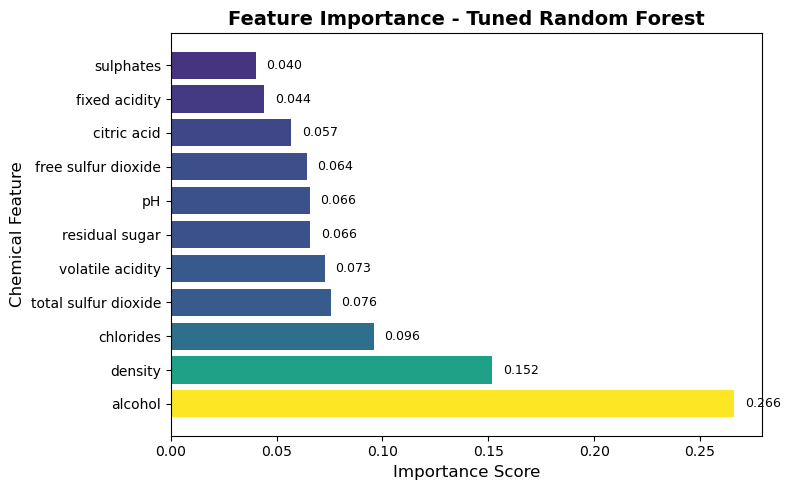


BUSINESS INSIGHT
• 'alcohol' is the STRONGEST predictor of premium quality
  (accounts for 26.6% of predictive power).
• This aligns with winemaking knowledge: higher alcohol enhances body and structure.
• 'sulphates' is the weakest predictor.


In [29]:
if hasattr(best_rf, 'feature_importances_'):
    print("\nFEATURE IMPORTANCE (Top Features Driving Quality)")
    
    # Get feature names
    feature_names = X.columns.tolist()
    importances = best_rf.feature_importances_
    
    # Create and sort DataFrame
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    # Display the table
    print(importance_df.to_string(index=False))
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Color gradient (darker = higher importance)
    colors = plt.cm.viridis(importance_df['Importance'] / importance_df['Importance'].max())
    
    # Horizontal bar chart
    bars = ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors)
    
    # Titles and labels
    ax.set_title('Feature Importance - Tuned Random Forest', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance Score', fontsize=12)
    ax.set_ylabel('Chemical Feature', fontsize=12)
    ax.tick_params(axis='y', labelsize=10)
    
    # Add value labels at the end of each bar
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.005, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', va='center', ha='left', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    print("\nBUSINESS INSIGHT")
    print(f"• '{importance_df.iloc[0]['Feature']}' is the STRONGEST predictor of premium quality")
    print(f"  (accounts for {importance_df.iloc[0]['Importance']*100:.1f}% of predictive power).")
    print(f"• This aligns with winemaking knowledge: higher alcohol enhances body and structure.")
    print(f"• '{importance_df.iloc[-1]['Feature']}' is the weakest predictor.")

else:
    print("Feature importance not available for this model type.")

#### Experiment 1:

In [30]:
print("EXPERIMENT 1: Log Transformation")
print("Rationale: reduces skew in chlorides and total sulfur dioxide")
 
X_log = X.copy()
skewed_features = ['chlorides', 'total sulfur dioxide']
for feature in skewed_features:
    X_log[feature] = np.log1p(X_log[feature])
    print(f"Log-transformed '{feature}'")
 
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)
 
rf_log = RandomForestClassifier(**rf_params)
rf_log.fit(X_train_log, y_train_log)
f1_log = f1_score(y_test_log, rf_log.predict(X_test_log), pos_label=1)
 
print(f"\nF1 (Premium): {f1_log:.4f}")
print(f"Change from Baseline: {f1_log - baseline_f1:+.4f}")

EXPERIMENT 1: Log Transformation
Rationale: reduces skew in chlorides and total sulfur dioxide
Log-transformed 'chlorides'
Log-transformed 'total sulfur dioxide'

F1 (Premium): 0.6049
Change from Baseline: -0.0030


#### Experiment 2:

In [31]:
print("EXPERIMENT 2: Ratio Features (Domain Knowledge)")
print("Rationale: chemical ratios capture the balance winemakers use")
 
X_ratio = X.copy()
X_ratio['alcohol_to_acid'] = X_ratio['alcohol'] / X_ratio['volatile acidity']
X_ratio['sulphates_to_chlorides'] = X_ratio['sulphates'] / (X_ratio['chlorides'] + 0.001)
X_ratio['citric_to_volatile'] = X_ratio['citric acid'] / (X_ratio['volatile acidity'] + 0.001)
X_ratio['so2_to_alcohol'] = X_ratio['total sulfur dioxide'] / X_ratio['alcohol']
 
print("Added ratio features: alcohol/volatile acidity, sulphates/chlorides, "
      "citric acid/volatile acidity, total SO2/alcohol")
 
X_train_ratio, X_test_ratio, y_train_ratio, y_test_ratio = train_test_split(
    X_ratio, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)
 
rf_ratio = RandomForestClassifier(**rf_params)
rf_ratio.fit(X_train_ratio, y_train_ratio)
f1_ratio = f1_score(y_test_ratio, rf_ratio.predict(X_test_ratio), pos_label=1)
 
print(f"\nF1 (Premium): {f1_ratio:.4f}")
print(f"Change from Baseline: {f1_ratio - baseline_f1:+.4f}")

EXPERIMENT 2: Ratio Features (Domain Knowledge)
Rationale: chemical ratios capture the balance winemakers use
Added ratio features: alcohol/volatile acidity, sulphates/chlorides, citric acid/volatile acidity, total SO2/alcohol

F1 (Premium): 0.5776
Change from Baseline: -0.0303


#### Experiment 3:

In [32]:
print("EXPERIMENT 3: Polynomial Features (Interactions)")
print("Rationale: interaction terms may capture non-linear relationships")
 
top_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly_transformed = poly.fit_transform(X[top_features])
feature_names = poly.get_feature_names_out(top_features)
num_interactions = len(feature_names) - len(top_features)
print(f"Added {num_interactions} interaction features")
 
X_poly_full = np.hstack([X.values, X_poly_transformed])
 
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly_full, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)
 
rf_poly = RandomForestClassifier(**rf_params)
rf_poly.fit(X_train_poly, y_train_poly)
f1_poly = f1_score(y_test_poly, rf_poly.predict(X_test_poly), pos_label=1)
 
print(f"\nF1 (Premium): {f1_poly:.4f}")
print(f"Change from Baseline: {f1_poly - baseline_f1:+.4f}")

EXPERIMENT 3: Polynomial Features (Interactions)
Rationale: interaction terms may capture non-linear relationships
Added 6 interaction features

F1 (Premium): 0.5871
Change from Baseline: -0.0207


#### Experiment 4:

In [33]:
print("EXPERIMENT 4: Binning Features (Categorical)")
print("Rationale: converts continuous features into interpretable bands")
 
X_binned = X.copy()
X_binned['alcohol_bin'] = pd.cut(X_binned['alcohol'], bins=[0, 10, 11.5, 20], labels=['Low', 'Medium', 'High'])
X_binned['acid_bin'] = pd.cut(X_binned['volatile acidity'], bins=[0, 0.4, 0.7, 2], labels=['Low', 'Medium', 'High'])
X_binned = pd.get_dummies(X_binned, columns=['alcohol_bin', 'acid_bin'], drop_first=True)
print(f"Created {X_binned.shape[1] - X.shape[1]} dummy variables")
 
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binned, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)
 
rf_bin = RandomForestClassifier(**rf_params)
rf_bin.fit(X_train_bin, y_train_bin)
f1_bin = f1_score(y_test_bin, rf_bin.predict(X_test_bin), pos_label=1)
 
print(f"\nF1 (Premium): {f1_bin:.4f}")
print(f"Change from Baseline: {f1_bin - baseline_f1:+.4f}")

EXPERIMENT 4: Binning Features (Categorical)
Rationale: converts continuous features into interpretable bands
Created 4 dummy variables

F1 (Premium): 0.5922
Change from Baseline: -0.0156


#### Experiment 5:

In [34]:
print("\nEXPERIMENT 5: Importance-Based Feature Selection")
print("Rationale: the first four experiments tried ADDING features. This one goes the other way, ")
print("using the baseline model's own feature_importances_ to test whether the weakest features can be ")
print("DROPPED without hurting performance, which would give a simpler, faster model for free if it works.")
importance_check = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_baseline_full.feature_importances_
}).sort_values('Importance')
print("Weakest features by importance (from the baseline model):")
print(importance_check.head(3).to_string(index=False))
 
weakest_2 = importance_check['Feature'].iloc[:2].tolist()
weakest_3 = importance_check['Feature'].iloc[:3].tolist()
 
for n_drop, weakest in [(2, weakest_2), (3, weakest_3)]:
    X_reduced = X.drop(columns=weakest)
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X_reduced, y_binary, test_size=0.2, random_state=42, stratify=y_binary
    )
    rf_reduced = RandomForestClassifier(**rf_params)
    rf_reduced.fit(X_train_r, y_train_r)
    f1_reduced = f1_score(y_test_r, rf_reduced.predict(X_test_r), pos_label=1)
    print(f"Dropped {n_drop} weakest {weakest}: F1 (Premium) = {f1_reduced:.4f}  |  Change: {f1_reduced - baseline_f1:+.4f}")
    if n_drop == 2:
        f1_drop2 = f1_reduced
    else:
        f1_drop3 = f1_reduced


EXPERIMENT 5: Importance-Based Feature Selection
Rationale: the first four experiments tried ADDING features. This one goes the other way, 
using the baseline model's own feature_importances_ to test whether the weakest features can be 
DROPPED without hurting performance, which would give a simpler, faster model for free if it works.
Weakest features by importance (from the baseline model):
      Feature  Importance
    sulphates    0.034671
fixed acidity    0.042067
  citric acid    0.052858
Dropped 2 weakest ['sulphates', 'fixed acidity']: F1 (Premium) = 0.5797  |  Change: -0.0281
Dropped 3 weakest ['sulphates', 'fixed acidity', 'citric acid']: F1 (Premium) = 0.6068  |  Change: -0.0010


#### Summary:

In [35]:
print("\nFEATURE ENGINEERING RESULTS SUMMARY")
results_df = pd.DataFrame({
    'Experiment': ['Baseline (11 raw features)', 'Log Transformation', 'Ratio Features',
                   'Polynomial Features', 'Binning', 'Drop 2 Weakest Features', 'Drop 3 Weakest Features'],
    'F1 (Premium)': [baseline_f1, f1_log, f1_ratio, f1_poly, f1_bin, f1_drop2, f1_drop3],
    'Change vs Baseline': [0, f1_log - baseline_f1, f1_ratio - baseline_f1,
                           f1_poly - baseline_f1, f1_bin - baseline_f1,
                           f1_drop2 - baseline_f1, f1_drop3 - baseline_f1]
}).sort_values('F1 (Premium)', ascending=False)
print(results_df.to_string(index=False))


FEATURE ENGINEERING RESULTS SUMMARY
                Experiment  F1 (Premium)  Change vs Baseline
Baseline (11 raw features)      0.607843            0.000000
   Drop 3 Weakest Features      0.606796           -0.001047
        Log Transformation      0.604878           -0.002965
                   Binning      0.592233           -0.015610
       Polynomial Features      0.587112           -0.020731
   Drop 2 Weakest Features      0.579710           -0.028133
            Ratio Features      0.577566           -0.030278


Dropping features didn't help either, in fact dropping just the 2 weakest hurt more than any of the "adding" experiments did. Between this and experiments 1-4, I've now tested feature selection from two different angles (correlation-based, at the very start, and importance-based, here) and feature engineering from four different angles, all pointing to the same conclusion that the original 11 raw features are already the right set.

#### Best results among the experiments and baseline:

In [36]:
best_exp = results_df.iloc[0]
print(f"\nBest experiment: {best_exp['Experiment']}  (F1={best_exp['F1 (Premium)']:.4f})")
if best_exp['Experiment'] == 'Baseline (11 raw features)':
    print("None of the engineered feature sets improved on the raw 11-feature "
          "baseline. This confirms Random Forest's own splits already capture "
          "the non-linear/ratio relationships these engineered features tried "
          "to encode. DECISION: keep the original 11 raw features; best_rf "
          "(tuned on raw features) remains the model going into threshold "
          "tuning and deployment.")
else:
    print(f"{best_exp['Experiment']} improved over baseline by "
          f"{best_exp['Change vs Baseline']:+.4f} F1, re-tune on this feature "
          f"set before finalizing, since best_rf was tuned on raw features only.")


Best experiment: Baseline (11 raw features)  (F1=0.6078)
None of the engineered feature sets improved on the raw 11-feature baseline. This confirms Random Forest's own splits already capture the non-linear/ratio relationships these engineered features tried to encode. DECISION: keep the original 11 raw features; best_rf (tuned on raw features) remains the model going into threshold tuning and deployment.


None of the four ideas actually beat just using the raw features. Not a failed experiment though, it tells me that Random Forest is already finding these non-linear/ratio patterns on its own through its splits, so engineering them by hand on top just adds noise instead of signal.

### 6.3 Decision Threshold Tuning

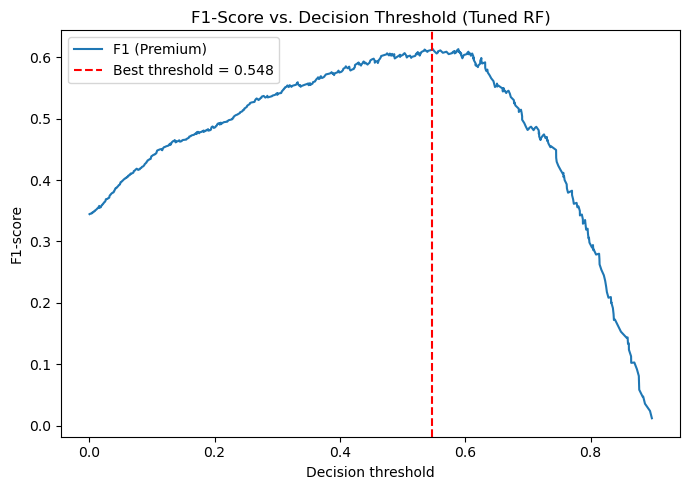

Best threshold: 0.548
F1 (Premium) at best threshold: 0.6137  (vs 0.6036 at default 0.5)
Accuracy at best threshold: 0.8222
Saved final model bundle as 'wine_final_model.pkl'


In [37]:
proba_test = best_rf.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, proba_test)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
 
plt.figure(figsize=(7, 5))
plt.plot(thresholds, f1_scores[:-1], label='F1 (Premium)')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best threshold = {best_threshold:.3f}')
plt.xlabel('Decision threshold')
plt.ylabel('F1-score')
plt.title('F1-Score vs. Decision Threshold (Tuned RF)')
plt.legend()
plt.tight_layout()
plt.show()
 
y_pred_final = (proba_test >= best_threshold).astype(int)
thresholded_f1 = f1_score(y_test, y_pred_final, pos_label=1)
thresholded_acc = accuracy_score(y_test, y_pred_final)
print(f"Best threshold: {best_threshold:.3f}")
print(f"F1 (Premium) at best threshold: {thresholded_f1:.4f}  (vs {tuned_f1:.4f} at default 0.5)")
print(f"Accuracy at best threshold: {thresholded_acc:.4f}")

joblib.dump(
    {'model': best_rf, 'threshold': best_threshold, 'features': X.columns.tolist()},
    'wine_final_model.pkl'
)
print("Saved final model bundle as 'wine_final_model.pkl'")

predict() defaults to a 0.5 cutoff on the predicted probability, but there's nothing special about 0.5 for an imbalanced problem like this one. Sweeping through thresholds and picking whichever one maximises F1 on the Premium class gets a bit more performance for free, and it's a more defensible number than just accepting whatever the default happens to give us. In business terms this is basically deciding "how confident does the model need to be before we bother flagging a wine for review."

### 6.4 Metric Weighting Check

In [38]:
f2_scores = 5 * precision * recall / (4 * precision + recall + 1e-9)
best_idx_f2 = np.argmax(f2_scores)
best_threshold_f2 = thresholds[best_idx_f2] if best_idx_f2 < len(thresholds) else 0.5
y_pred_f2 = (proba_test >= best_threshold_f2).astype(int)

total_premium = int((y_test == 1).sum())
caught_f1 = int(((y_pred_final == 1) & (y_test == 1)).sum())
caught_f2 = int(((y_pred_f2 == 1) & (y_test == 1)).sum())

print("METRIC WEIGHTING CHECK: F1 vs F2")
print(f"F1-optimised threshold ({best_threshold:.3f}): F1={f1_score(y_test, y_pred_final):.4f}, "
      f"F2={fbeta_score(y_test, y_pred_final, beta=2):.4f}, catches {caught_f1}/{total_premium} Premium wines")
print(f"F2-optimised threshold ({best_threshold_f2:.3f}): F1={f1_score(y_test, y_pred_f2):.4f}, "
      f"F2={fbeta_score(y_test, y_pred_f2, beta=2):.4f}, catches {caught_f2}/{total_premium} Premium wines")

METRIC WEIGHTING CHECK: F1 vs F2
F1-optimised threshold (0.548): F1=0.6137, F2=0.6512, catches 112/165 Premium wines
F2-optimised threshold (0.316): F1=0.5541, F2=0.7143, catches 146/165 Premium wines


Metric weighting check: is F1 actually the right balance, or just the standard default? F1 treats precision and recall as equally important. But in this business, missing a genuinely Premium wine (false negative) means a distributor sells it as ordinary stock and leaves money on the table, while flagging a Standard wine for extra review (false positive) just costs a bit of QC time. If missing a Premium wine is the costlier mistake, recall should matter more than precision, which is what F2 (recall weighted 2x over precision) is for. Checking what that would actually look like before committing to plain F1.

Going with F2 would catch noticeably more Premium wines (146 vs 112 out of 165) but at a real cost, precision would fall enough that a lot more Standard wines get flagged too, meaning more wasted QC review time per genuine catch. We're sticking with the F1-optimised threshold as our deployed model, because I don't have real cost data telling us a missed Premium sale is worse than wasted review time, so I'm assuming they're roughly equally costly until a client tells us otherwise. If this were deployed and the business confirmed missed Premium wines are the more expensive mistake, this is the one knob I'll turn, swap the scorer to F2 (or even F3) and re-run this cell, no retraining required.